# Netra-NMT — Multi-Metric Benchmark
**Dataset:** ALT (`mutiyama/alt`), test split, n = 1 018 pairs.

Reads the per-model JSON result files in `results/` and renders a single
**5 × 2** figure (5 metrics × 2 directions) in the Netra brand style,
saved to `assets/metrics_benchmark.png` at **300 DPI**.

> Run with the kernel CWD set to the repo root (`d:\\Netra-NMT`).

In [5]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import seaborn as sns

# ── Colour helpers ────────────────────────────────────

def _warm_gray(level):
    """Warm-tinted gray; level 0 = near-black, 1 = near-white."""
    r = min(1.0, level + 0.03)
    g = min(1.0, level - 0.01)
    b = min(1.0, level - 0.04)
    return f"#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}"

# ── Brand palette ───────────────────────────────────
C_PRIMARY = "#e75f1b"
C_BG      = "#ffffff"
C_PANEL   = "#ffffff"
C_TEXT    = "#1c1c1c"
C_MUTED   = "#888888"

# Netra keeps the vivid brand orange; baselines are warm greys, light → dark.
MODEL_COLORS = {
    "Netra NMT (Ours)": C_PRIMARY,
    "NLLB-350M":        _warm_gray(0.55),
    "NLLB-600M":        _warm_gray(0.66),
    "NLLB-1.3B":        _warm_gray(0.76),
    "Madlad-3B":        _warm_gray(0.86),
    "Google Translate": _warm_gray(0.40),
}
MODEL_ORDER = [
    "Netra NMT (Ours)", "NLLB-350M", "NLLB-600M",
    "NLLB-1.3B", "Madlad-3B", "Google Translate",
]

# ── Font & theme (same stack as compare_models.ipynb) ───────────────
_FONTS = ["Segoe UI", "Noto Sans Khmer", "DejaVu Sans"]
mpl.rcParams["font.family"]     = "sans-serif"
mpl.rcParams["font.sans-serif"] = _FONTS

sns.set_theme(style="white", rc={
    "font.family":      "sans-serif",
    "font.sans-serif":  _FONTS,
    "axes.facecolor":   C_PANEL,
    "figure.facecolor": C_BG,
})

print("Setup complete.")

Setup complete.


In [6]:
# ── Result files (one JSON per model) ────────────────────────
FILES = {
    "Netra NMT (Ours)": Path("../results/eval_results_alt.json"),
    "NLLB-350M":        Path("../results/eval_results_lyfeyvutha_350M_alt.json"),
    "NLLB-600M":        Path("../results/eval_results_nllb200_alt.json"),
    "NLLB-1.3B":        Path("../results/eval_results_nllb1.3B_alt.json"),
    "Madlad-3B":        Path("../results/eval_results_madlad3b_alt.json"),
    "Google Translate": Path("../results/google_translate_alt.json"),
}

# (json_key, display label, axis floor, higher_is_better)
# BERTScore floor is 75 (not 80) so the degenerate NLLB-350M KH→EN bar (78.65)
# still renders; everything else starts at 0.
METRICS = [
    ("spbleu",       "spBLEU",       0,  True),
    ("chrf_pp",      "chrF++",       0,  True),
    ("ter",          "TER",          0,  False),
    ("comet",        "COMET",        0,  True),
    ("bertscore_f1", "BERTScore F1", 75, True),
]

DIR_NORM = {"EN→KH": "EN_KH", "KH→EN": "KH_EN"}

rows = []
for model, path in FILES.items():
    data = json.loads(path.read_text(encoding="utf-8"))
    for entry in data["results"]:
        direction = DIR_NORM[entry["direction"]]
        for key, label, _floor, _hib in METRICS:
            rows.append({
                "Model":     model,
                "Direction": direction,
                "Metric":    label,
                "Score":     float(entry[key]),
            })

df = pd.DataFrame(rows)
print("df shape:", df.shape)        # expect (60, 4) = 6 models x 2 dirs x 5 metrics
df.head()

df shape: (60, 4)


,Model,Direction,Metric,Score
0,Netra NMT (Ours),EN_KH,spBLEU,25.39
1,Netra NMT (Ours),EN_KH,chrF++,37.15
2,Netra NMT (Ours),EN_KH,TER,61.95
3,Netra NMT (Ours),EN_KH,COMET,77.22
4,Netra NMT (Ours),EN_KH,BERTScore F1,89.92


In [ ]:
# ── Panel drawing helper ────────────────────────────────

def _spine_clean(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#e0e0e0")
    ax.spines["bottom"].set_color("#e0e0e0")


def plot_panel(ax, direction, metric_label, floor):
    """Draw one metric/direction panel: 6 model bars + value labels."""
    subset  = df[(df["Direction"] == direction) & (df["Metric"] == metric_label)]
    present = [m for m in MODEL_ORDER if m in subset["Model"].values]
    scores  = dict(zip(subset["Model"], subset["Score"]))

    sns.barplot(
        data=subset, x="Model", y="Score",
        order=present,
        hue="Model", palette={m: MODEL_COLORS[m] for m in present}, legend=False,
        ax=ax, width=0.70, linewidth=0,
        err_kws={"linewidth": 0}, capsize=0,
    )

    y_max  = max(scores[m] for m in present)
    y_span = y_max - floor
    ax.set_ylim(floor, y_max + y_span * 0.26)

    patches = [p for p in ax.patches if p.get_width() > 0.01][:len(present)]
    for patch, model in zip(patches, present):
        h  = patch.get_height()
        cx = patch.get_x() + patch.get_width() / 2
        ax.text(cx, h + y_span * 0.04, f"{h:.2f}",
                ha="center", va="bottom",
                fontsize=8, fontweight="bold", color=MODEL_COLORS[model])

    ax.set_facecolor(C_PANEL)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.tick_params(axis="y", labelsize=8, colors=C_MUTED, length=0, pad=3)
    ax.yaxis.grid(True, color="#efefef", linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    _spine_clean(ax)

print("Helper ready.")

Helper ready.


Saved: assets/metrics_benchmark.png


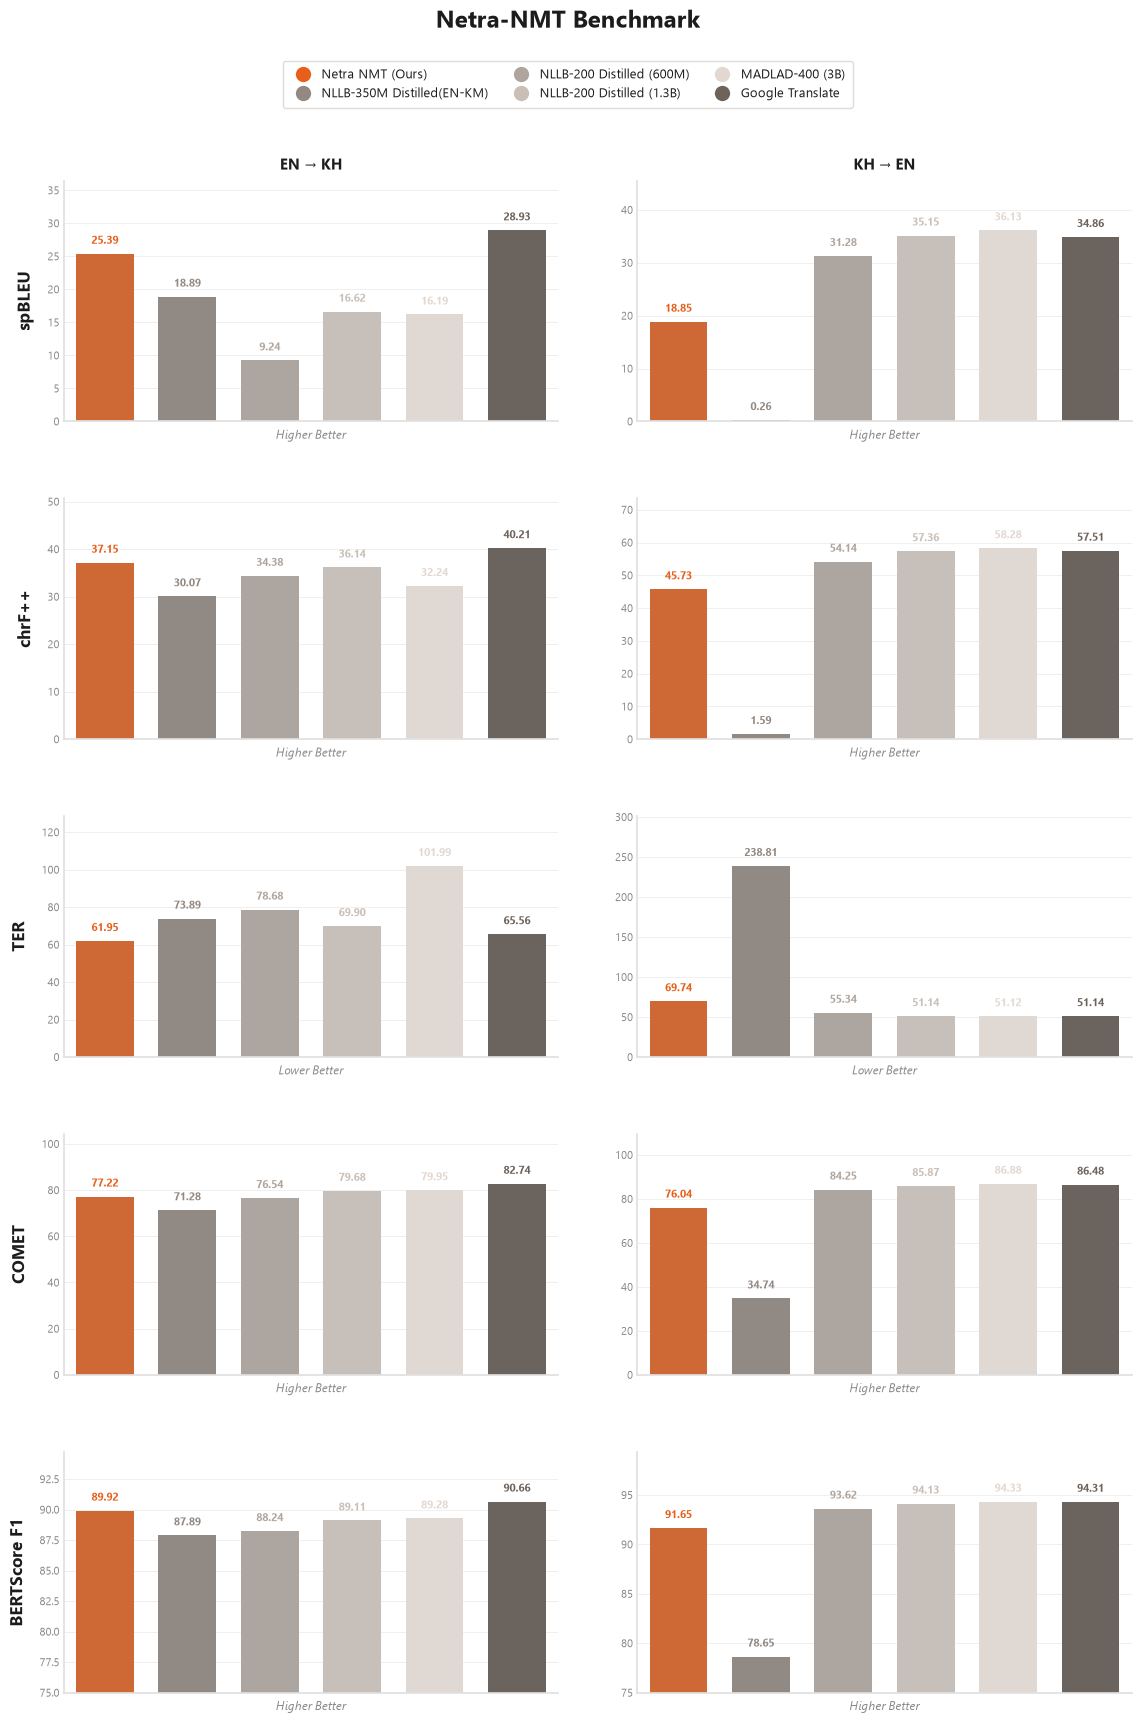

In [13]:
# ── Assemble the 5 x 2 figure ───────────────────────────
DIR_TITLE = {"EN_KH": "EN → KH", "KH_EN": "KH → EN"}

fig, axes = plt.subplots(5, 2, figsize=(12, 18), facecolor=C_BG)
fig.subplots_adjust(top=0.88, bottom=0.04, left=0.08, right=0.97,
                    hspace=0.32, wspace=0.16)

fig.suptitle("Netra-NMT Benchmark",
             fontsize=17, fontweight="bold", color=C_TEXT, y=0.975)

# ── Shared dot legend (6 models, 3 per row) ────────────────────
DISPLAY = {
    "Netra NMT (Ours)": "Netra NMT (Ours)",
    "NLLB-350M":        "NLLB-350M Distilled(EN-KM)",
    "NLLB-600M":        "NLLB-200 Distilled (600M)",
    "NLLB-1.3B":        "NLLB-200 Distilled (1.3B)",
    "Madlad-3B":        "MADLAD-400 (3B)",
    "Google Translate": "Google Translate",
}
handles = [
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor=MODEL_COLORS[m], markersize=11,
           label=DISPLAY[m], markeredgewidth=0)
    for m in MODEL_ORDER
]
fig.legend(
    handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.95),
    ncol=3, frameon=True, fontsize=9, labelcolor=C_TEXT,
    handletextpad=0.5, columnspacing=1.6, borderpad=0.6,
    fancybox=True, framealpha=0.95, edgecolor="#e0d8d4",
)

for row, (key, label, floor, hib) in enumerate(METRICS):
    for col, direction in enumerate(["EN_KH", "KH_EN"]):
        ax = axes[row, col]
        plot_panel(ax, direction, label, floor)

        if row == 0:
            ax.set_title(DIR_TITLE[direction], fontsize=11,
                         fontweight="bold", color=C_TEXT, pad=8)

        caption = "Higher Better" if hib else "Lower Better"
        ax.set_xlabel(caption, fontsize=8.5, color=C_MUTED,
                      style="italic", labelpad=6)

        if col == 0:                       # row label on the left panel
            ax.set_ylabel(label, fontsize=12, fontweight="bold",
                          color=C_TEXT, labelpad=10)

Path("assets").mkdir(exist_ok=True)
fig.savefig("assets/metrics_benchmark.png", dpi=300,
            bbox_inches="tight", facecolor=C_BG)
print("Saved: assets/metrics_benchmark.png")
plt.show()

## Notes
- **TER is lower-is-better** — its row is captioned *Lower Better*; all other rows are *Higher Better*.
- The **NLLB-350M (lyfeyvutha) KH→EN** result is a degenerate run (spBLEU 0.26, chrF++ 1.59,
  TER 238.81, COMET 34.74). It is shown as-is for honesty; its large TER value stretches that
  panel's y-axis, but the printed value labels keep every bar's real number legible.